In [2]:
!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf \
    -O fonts/NanumGothic.ttf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지


In [3]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(13) # 숙제 번호 13을 시드로 (재현 가능성)

N = 150
genre = rng.choice(['뉴스', '소설', '대화', '학술'], size=N, p=[0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28} # 장르별 평균 어절 수
words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)
syllables = (words * 2.5 + rng.normal(0, 4, N)).clip(5, None).round().astype(int)
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)

texts = pd.DataFrame({
    '장르': genre,
    '어절수': words,
    '음절수': syllables,
    '읽기시간': read_time,
    '난이도': difficulty,
})

# 연도별 신문/소설의 외래어 비율(%) (가상 데이터)
trends = pd.DataFrame({
    '연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
    '뉴스': [5.1, 6.3, 8.0, 9.4, 11.2, 13.5, 15.1],
    '소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4],
})

texts

,장르,어절수,음절수,읽기시간,난이도
0,학술,21,54,18.2,2.6
1,학술,30,78,29.4,5.5
2,학술,38,96,33.1,5.9
3,뉴스,21,53,20.4,2.5
4,뉴스,26,68,24.6,4.5
...,...,...,...,...,...
145,뉴스,23,55,21.1,2.5
146,뉴스,21,49,18.3,1.6
147,학술,28,72,24.9,4.2
148,소설,9,24,6.5,2.0


In [7]:
#Q1
#(a)
counts = texts['장르'].value_counts()
counts

장르
소설    54
뉴스    36
학술    32
대화    28
Name: count, dtype: int64

(0.0, 60.0)

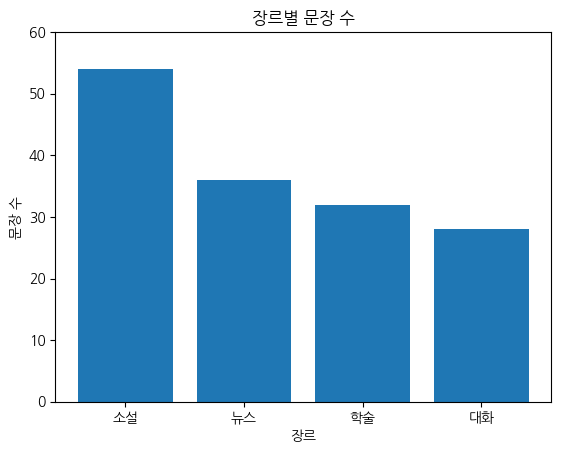

In [8]:
fig, ax = plt.subplots()
ax.bar(counts.index, counts.values)
ax.set_title('장르별 문장 수')
ax.set_xlabel('장르')
ax.set_ylabel('문장 수')
ax.set_ylim(0, 60)

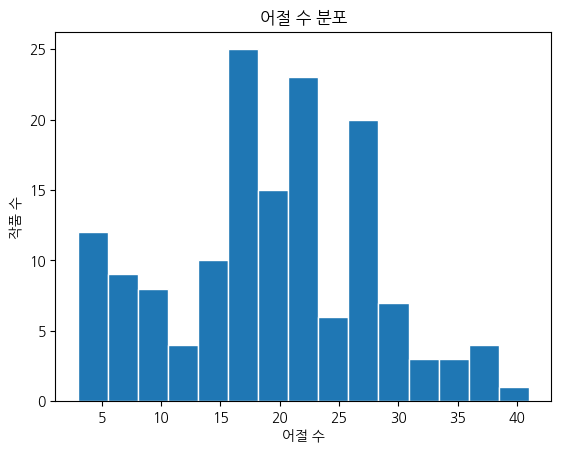

In [11]:
#(b)
fig, ax = plt.subplots()
ax.hist(texts['어절수'], bins=15, edgecolor='white')
ax.set_title('어절 수 분포')
ax.set_xlabel('어절 수')
ax.set_ylabel('작품 수')
plt.show()

관찰 (한 문장) : 15~28어절에 몰려 있음.

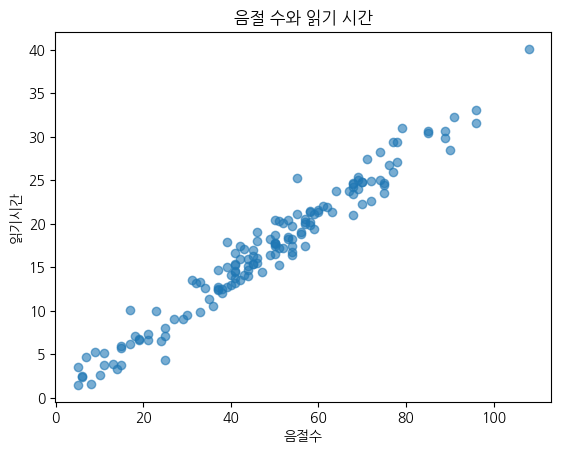

In [12]:
#(c)
fig, ax = plt.subplots()
ax.scatter(texts['음절수'], texts['읽기시간'], alpha=0.6)
ax.set_title('음절 수와 읽기 시간')
ax.set_xlabel('음절수')
ax.set_ylabel('읽기시간')
plt.show()

관찰 (한 문장) : 우상향 관계를 보임.

Text(0, 0.5, '외래어 비율')

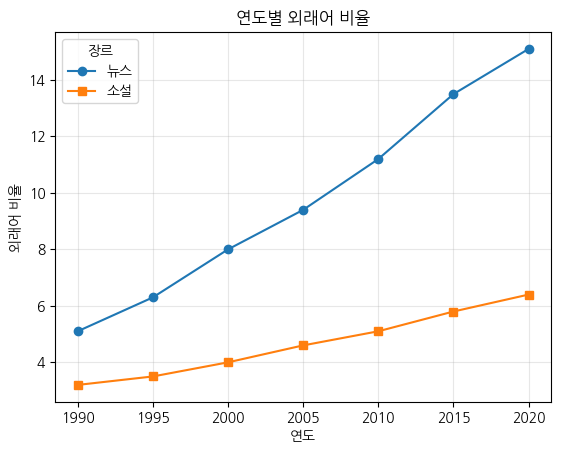

In [27]:
#Q2 (a)

fig, ax = plt.subplots()
ax.plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
ax.plot(trends['연도'], trends['소설'], marker='s', label='소설')
ax.legend(title='장르')
ax.grid(True, alpha=0.3)
ax.set_title('연도별 외래어 비율')
ax.set_xlabel('연도')
ax.set_ylabel('외래어 비율')

관찰 (한 문장) : 소설보다 뉴스에서 외래어 증가율이 더 가파르다.

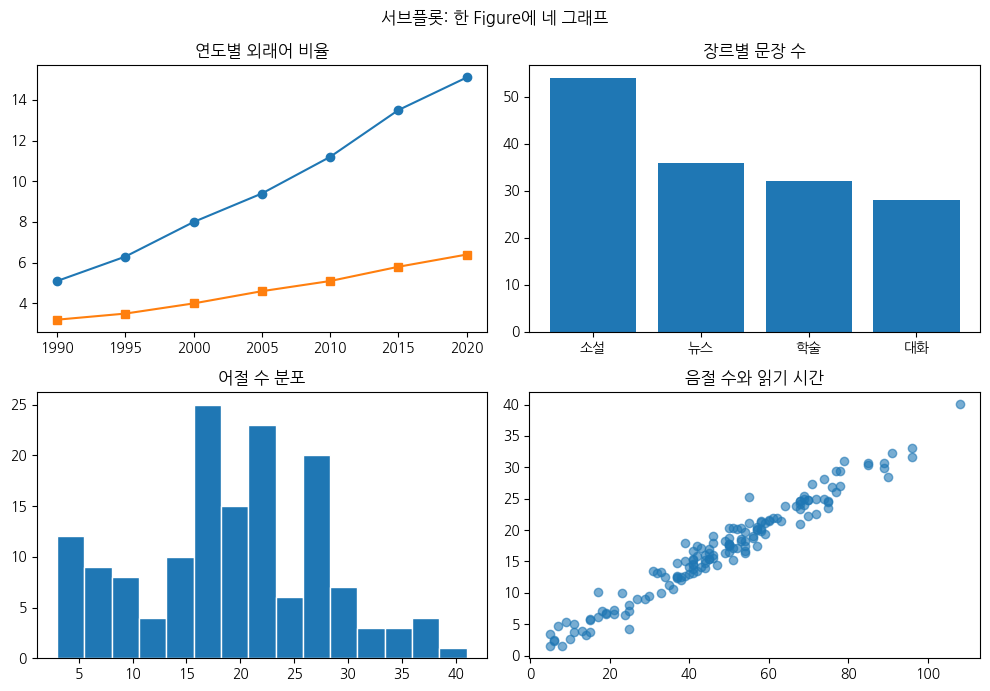

In [16]:
#(b)
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0, 0].plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
axes[0, 0].plot(trends['연도'], trends['소설'], marker='s', label='소설')
axes[0, 0].set_title('연도별 외래어 비율')

axes[0, 1].bar(counts.index, counts.values)
axes[0, 1].set_title('장르별 문장 수')
# axes[0, 1].set_ylim(0, 60)

axes[1, 0].hist(texts['어절수'], bins=15, edgecolor='white')
axes[1, 0].set_title('어절 수 분포')

axes[1, 1].scatter(texts['음절수'], texts['읽기시간'], alpha=0.6)
axes[1, 1].set_title('음절 수와 읽기 시간')

fig.suptitle('서브플롯: 한 Figure에 네 그래프')
fig.tight_layout()
fig.savefig('hw13_subplots.png', dpi=150, bbox_inches='tight')

Text(0.5, 1.0, '장르별 색칠')

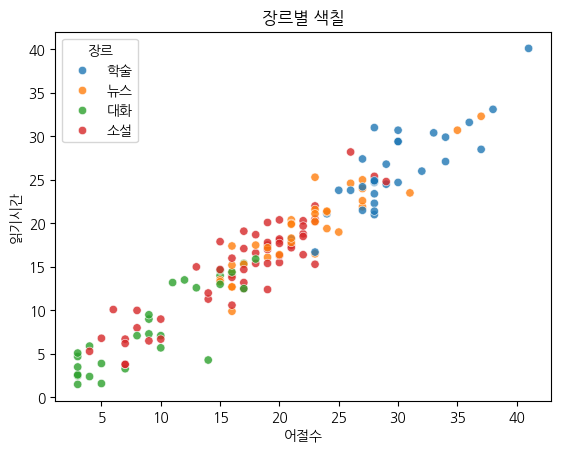

In [9]:
#Q3 (a)
import seaborn as sns
fig, ax = plt.subplots()

sns.scatterplot(
    data = texts,
    x = '어절수',
    y = '읽기시간',
    hue = '장르',
    ax = ax,
    alpha = 0.8
)

ax.set_title('장르별 색칠')

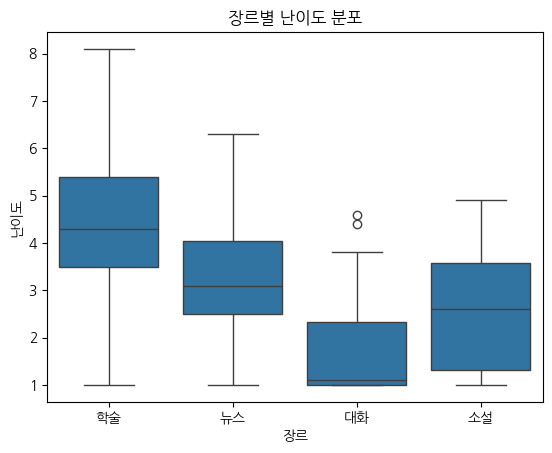

In [25]:
#(b)
fig, ax = plt.subplots()

sns.boxplot(
    data = texts,
    x='장르',
    y='난이도',
    ax=ax
)
ax.set_title('장르별 난이도 분포')
plt.show()

관찰 (한 문장) : 가장 난이도가 높은 장르는 학술. 퍼짐이 가장 큰 장르는 소설.

In [ ]:
#(c)
texts2 = texts.drop(columns=['장르'])
texts2

,어절수,음절수,읽기시간,난이도
0,21,54,18.2,2.6
1,30,78,29.4,5.5
2,38,96,33.1,5.9
3,21,53,20.4,2.5
4,26,68,24.6,4.5
...,...,...,...,...
145,23,55,21.1,2.5
146,21,49,18.3,1.6
147,28,72,24.9,4.2
148,9,24,6.5,2.0


In [7]:
corr = texts2.corr()
corr

,어절수,음절수,읽기시간,난이도
어절수,1.000000,0.983284,0.957788,0.779660
음절수,0.983284,1.000000,0.979388,0.776478
읽기시간,0.957788,0.979388,1.000000,0.774815
난이도,0.779660,0.776478,0.774815,1.000000


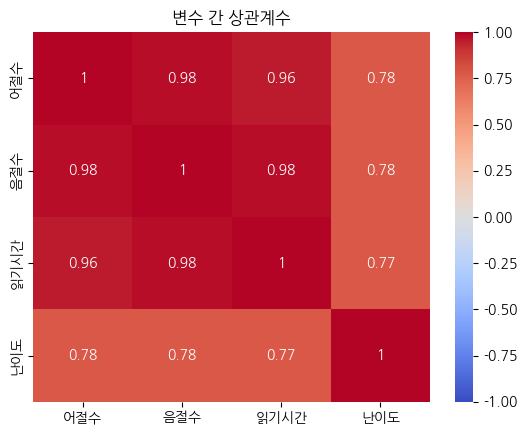

In [10]:
fig, ax = plt.subplots()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('변수 간 상관계수')
plt.show()

관찰 (한두 문장): 서로 가장 강하게 함께 증가하는 두 변수는 음절 수와 어절 수이다. 그 이유는 한 작품의 어절 수가 증가하면 거의 정비례하게 음절 수도 증가하기 때문이다.

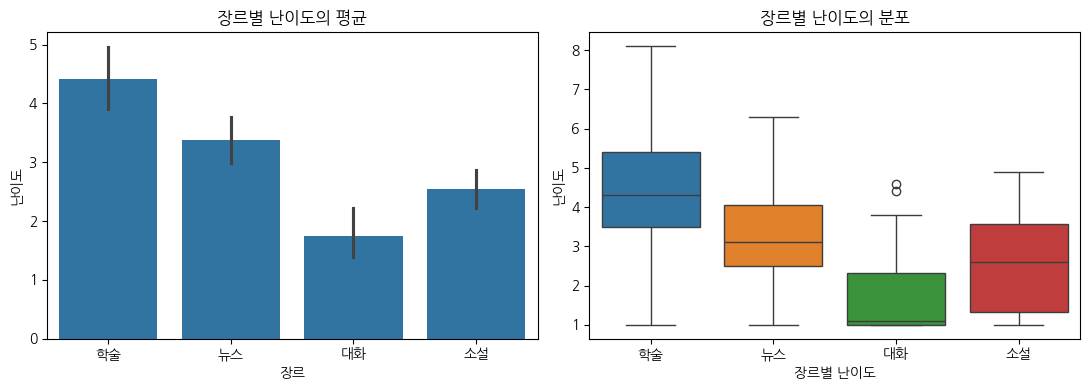

In [11]:
#Q4 (a)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=texts, x='장르', y='난이도', ax=axes[0])
axes[0].set_title('장르별 난이도의 평균')

sns.boxplot(data=texts, x='장르', y='난이도', hue='장르', ax=axes[1])
axes[1].set_title('장르별 난이도의 분포')
axes[1].set_xlabel('장르별 난이도')

fig.tight_layout()

서술 (두세 문장).
왼쪽 막대 그래프에서는 평균만을 강조하여 최댓값, 최솟값, outlier, 중앙값, 난이도의 분포 모양 등 알 수 없는 정보가 많다. 그래프의 y축도 0~5까지만 보여주고 있어 최대 8까지 분포된 '학술' 분야에 대한 정보를 숨기고 있다. 같은 평균, 표준편차값을 가진 데이터이더라도 전혀 다른 분포를 가질 수 있기 때문에 오른쪽 그래프보다 숨기는 정보가 많음을 알 수 있다.

In [12]:
#(b)
texts.groupby('장르')['어절수'].mean()

장르
뉴스    21.916667
대화     9.321429
소설    16.796296
학술    29.093750
Name: 어절수, dtype: float64

(0.0, 30.0)

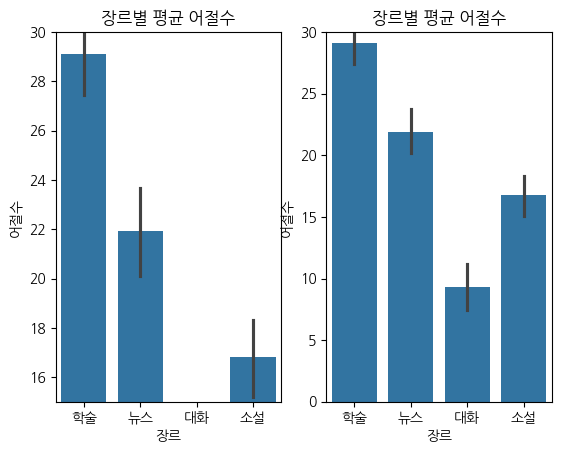

In [13]:
fig, axes = plt.subplots(1, 2)

sns.barplot(data=texts, x='장르', y='어절수', ax=axes[0])
axes[0].set_title('장르별 평균 어절수')
axes[0].set_ylim(15, 30)

sns.barplot(data=texts, x='장르', y='어절수', ax=axes[1])
axes[1].set_title('장르별 평균 어절수')
axes[1].set_xlabel('장르')
axes[1].set_ylim(0, 30)

서술 : 왼쪽 그래프의 경우, 대화 장르의 어절 수는 아예 없는 것으로 보인다. 15 미만이라는 것은 알 수 있지만 그 미만 수에 대한 정보가 없기 때문에 데이터 자체가 확인 불가이다. 따라서 데이터의 누락, 왜곡 등을 예방하기 위해 y축은 0부터 그리는 것이 바람직하다.